# Lendo páginas da Internet
Use os pacotes `rvest` e `xml2`.

In [ ]:
library(tidyverse)
library(xml2)
library(rvest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rvest’


The following object is masked from ‘package:readr’:

    guess_encoding




In [ ]:
url <- read_html("https://kworb.net/spotify/country/global_daily.html")

#url

# No que se segue:
# html_table(url) extrai todas as tabelas do url acima
#tabelas <- html_table(url)
#tabelas

spotify200 <- html_table(url)[[1]]

spotify200

Pos,P+,Artist and Title,Days,Pk,(x?),Streams,Streams+,7Day,7Day+,Total
<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,=,Taylor Swift - Fortnight (w/ Post Malone),4,1,(x4),"13,615,906","+1,535,726","64,947,834","+13,615,906","64,947,834"
2,+1,Taylor Swift - Down Bad,4,2,(x2),"8,774,157","+909,310","43,762,852","+8,774,157","43,762,852"
3,+1,Taylor Swift - I Can Do It With a Broken Heart,4,3,(x1),"8,543,631","+1,029,738","38,779,076","+8,543,631","38,779,076"
4,-2,Artemas - i like the way you kiss me,34,1,(x14),"8,357,829","+229,366","62,063,385","-1,006,573","235,618,342"
5,=,"Taylor Swift - So Long, London",4,4,,"8,000,728","+632,287","41,753,678","+8,000,728","41,753,678"
6,+1,FloyyMenor - Gata Only (w/ Cris Mj),73,2,(x1),"7,655,254","+589,363","55,014,511","+408,633","311,427,125"
7,-1,Taylor Swift - The Tortured Poets Department,4,2,(x1),"7,297,170","+210,062","42,697,165","+7,297,170","42,697,165"
8,=,Taylor Swift - My Boy Only Breaks His Favorite Toys,4,5,,"7,249,820","+441,444","39,807,777","+7,249,820","39,807,777"
9,+2,Hozier - Too Sweet,32,2,(x10),"7,015,917","+984,657","52,244,900","-1,455,489","206,316,805"


In [ ]:
spotify200_v2 <- spotify200 %>%
  mutate(Streams = parse_number(Streams),
         `Streams+` = parse_number(`Streams+`),
         `7Day` = parse_number(`7Day`),
         `7Day+` = parse_number(`7Day+`),
         Total = parse_number(Total),
         `P+` = parse_number(str_replace(`P+`, "=", "0")))

head(spotify200_v2, 30)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `P+ = parse_number(str_replace(`P+`, "=", "0"))`.
Caused by warning:
! 14 parsing failures.
row col expected actual
151  -- a number    NEW
173  -- a number    RE 
175  -- a number    RE 
176  -- a number    RE 
178  -- a number    RE 
... ... ........ ......
See problems(...) for more details.”


Pos,P+,Artist and Title,Days,Pk,(x?),Streams,Streams+,7Day,7Day+,Total
<int>,<dbl>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,Taylor Swift - Fortnight (w/ Post Malone),4,1,(x4),13615906,1535726,64947834,13615906,64947834
2,1,Taylor Swift - Down Bad,4,2,(x2),8774157,909310,43762852,8774157,43762852
3,1,Taylor Swift - I Can Do It With a Broken Heart,4,3,(x1),8543631,1029738,38779076,8543631,38779076
4,-2,Artemas - i like the way you kiss me,34,1,(x14),8357829,229366,62063385,-1006573,235618342
5,0,"Taylor Swift - So Long, London",4,4,,8000728,632287,41753678,8000728,41753678
6,1,FloyyMenor - Gata Only (w/ Cris Mj),73,2,(x1),7655254,589363,55014511,408633,311427125
7,-1,Taylor Swift - The Tortured Poets Department,4,2,(x1),7297170,210062,42697165,7297170,42697165
8,0,Taylor Swift - My Boy Only Breaks His Favorite Toys,4,5,,7249820,441444,39807777,7249820,39807777
9,2,Hozier - Too Sweet,32,2,(x10),7015917,984657,52244900,-1455489,206316805


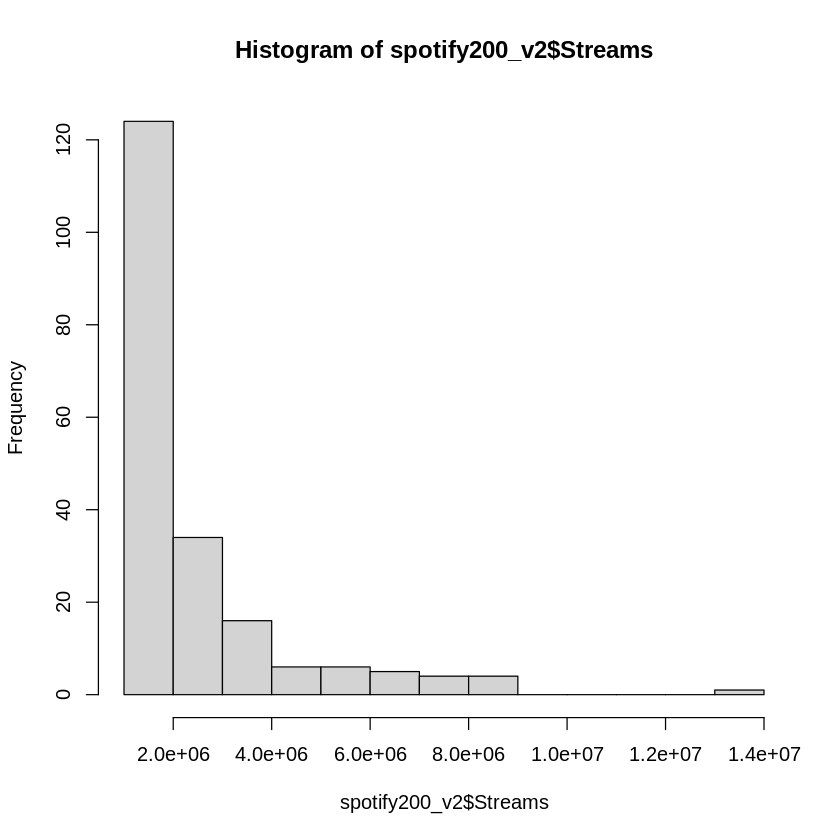

In [ ]:
hist(spotify200_v2$Streams)

In [ ]:
spotify200_v2 %>%
  filter(str_detect(`Artist and Title`, "Taylor Swift"))

Pos,P+,Artist and Title,Days,Pk,(x?),Streams,Streams+,7Day,7Day+,Total
<int>,<dbl>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,Taylor Swift - Fortnight (w/ Post Malone),4,1,(x4),13615906,1535726,64947834,13615906,64947834
2,1,Taylor Swift - Down Bad,4,2,(x2),8774157,909310,43762852,8774157,43762852
3,1,Taylor Swift - I Can Do It With a Broken Heart,4,3,(x1),8543631,1029738,38779076,8543631,38779076
5,0,"Taylor Swift - So Long, London",4,4,,8000728,632287,41753678,8000728,41753678
7,-1,Taylor Swift - The Tortured Poets Department,4,2,(x1),7297170,210062,42697165,7297170,42697165
8,0,Taylor Swift - My Boy Only Breaks His Favorite Toys,4,5,,7249820,441444,39807777,7249820,39807777
10,-1,Taylor Swift - But Daddy I Love Him,4,6,,6874761,437998,37103274,6874761,37103274
11,-1,Taylor Swift - Who’s Afraid of Little Old Me?,4,9,,6648890,530782,33405193,6648890,33405193
12,0,Taylor Swift - Florida!!! (w/ Florence + The Machine),4,7,,6483516,455141,34754834,6483516,34754834


# Manipulando texto
A biblioteca `stringr` tem algumas funções para manipulação de texto (_strings_). Esse pacote é carregado quando carregamos `tidyverse`.

Use `library(stringr)` para usar só `stringr`. Algumas funções:
* `str_length`: quantidade de caracteres no texto
* `str_to_upper`: deixa tudo MAIÚSCULO
* `str_to_lower`: deixa tudo minúsculo
* `str_to_title`: cada palavra fica com a primeira maiúscula
* `str_trim`: tira espaços a mais no começo ou final de texto
* `str_sub`: extrai parte de um texto
* `str_split`: separa texto


In [ ]:
estados <- c("Acre", "São Paulo", "Rio de Janeiro", "Minas Gerais")
str_length(estados)
length(estados)

In [ ]:
str_to_upper(estados)
str_to_lower(estados)
str_to_title(estados)

In [ ]:
"Acre" == "Acre    "

In [ ]:
genero <- c("F", " F", " M   ", "M")
str_trim(genero)

estados <- c("Acre", "São   Paulo", "Rio de   Janeiro  ", "  Minas Gerais  ")
str_trim(estados)

In [ ]:
genero <- c("F - Feminino", "M - Masculino", "N - Não binário")
str_sub(genero, start=5)
str_sub(genero, start=1, end=1)
str_sub(genero, end=1)

genero2 <- c("Feminino (F)", "Masculino (M)", "Não binário (N)")
str_sub(genero2, end=-5)
str_sub(genero2, start=-3)
str_sub(genero2, start=-2, end=-2)

In [ ]:
destinos <- c("São Paulo - SP - Brasil",
              "Belo Horizonte - MG - Brasil",
              "Rio de Janeiro - RJ - Brasil",
              "New York - NJ - USA")

(separados <- str_split(destinos, pattern = " - "))

class(separados)

# sapply aplica uma função em cada elemento de uma lista
# [[ simplesmente acessa o elemento da lista
# o número que segue indica cada elemento

?sapply

(cidades <- sapply(separados,"[[",1))  # elemento 1 de cada lista
(estados <- sapply(separados,"[[",2))  # elemento 2 de cada lista
(paises  <- sapply(separados,"[[",3))  # elemento 3 de cada lista

destinos2 <- data.frame(Cidade = cidades, Estado = estados, País = paises)

destinos2

## Exercícios
1. O CPF é um número de 11 dígitos, por exemplo: 54491651884. No entanto para facilitar a visualização costumamos mostrá-lo com separadores a cada 3 casas: 544.916.518-84. Crie uma função que transforma um número de 11 dígitos em uma string com as separações, como um CPF.

In [ ]:
num <- 1
digitos <- str_length(as.character(num))
digitos

paste(c(rep(0,11-digitos),num), collapse="")

In [ ]:
# Solução
cpf <- function(num){
  digitos <- str_length(as.character(num))
  texto <- paste(c(rep(0,11-digitos),num), collapse="")

  comeco <- str_sub(texto, start=1, end=3)
  meio <- str_sub(texto, start=4, end=6)
  fim <- str_sub(texto, start=7, end=9)
  verif <- str_sub(texto, start=10)

  return(paste0(comeco, ".", meio, ".", fim, "-", verif))
}

cpf(00000020001)

2. Transforme o vetor de strings abaixo em `"01 - Alto" "02 - Médio" "03 - Baixo"`.

In [ ]:
s <- c('Alto', 'Médio', 'Baixo')

# Solução


## Mais um exemplo
Aqui, vamos fazer o scraping e depois ajeitar os textos.

In [ ]:
brasileirao <- read_html("https://www.uol.com.br/esporte/futebol/campeonatos/brasileirao/")

tabela <- html_table(brasileirao, header=TRUE)

#tabela
(classificacao <- cbind(tabela[[1]],tabela[[2]]))

In [ ]:
classificacao %>%
  mutate(classificação = str_sub(classificação, start=4, end=-4))

# Mais um exemplo
Agora vamos ver os resultados do heptatlo.

In [ ]:
heptatlo <- read_html("https://en.wikipedia.org/wiki/Athletics_at_the_2020_Summer_Olympics_%E2%80%93_Women%27s_heptathlon")

In [ ]:
tabelas_heptatlo <- html_table(heptatlo)
tabelas_heptatlo

# Exercícios
Considere os resultados dos 100 metros com barreiras (tabela 7, ou seja, `tabelas_heptatlo[[7]]`).

In [ ]:
cem_barreiras <- tabelas_heptatlo[[7]]
cem_barreiras

1. (Revisão) Quais atletas obtiveram seu recorde pessoal (PB)?

In [ ]:
cem_barreiras %>%
  filter(Notes == "PB") %>%
  select(Athlete, Nation, Time)

2. Ajeite a coluna `Time` para ser um valor numérico. Os parêntesis aumentam a quantidade de casas decimais; por exemplo, `13.27 (.261)` significa que o tempo é `13.261`.

In [ ]:
ajeita <- function(tempo){
  if(str_length(tempo) > 5){
    resposta <- parse_number(paste0(str_sub(tempo, start=1, end=2),str_sub(tempo, start=-5, end=-2)))
  }
  else
    resposta <- parse_number(tempo)
  return(resposta)
}

ajeita_v <- Vectorize(ajeita)

cem_barreiras %>%
  mutate(Time = ajeita_v(Time))

Agora considere os resultados dos 800 metros rasos, na tabela 13 (sim, `tabelas_heptatlo[[13]]`).

3. Converta o tempo para um formato que permita contas (use a função `lubridate`; ajuda em https://rstudio.github.io/cheatsheets/html/lubridate.html). Em seguida, calcule, para cada atleta, a diferença de tempo com relação à vencedora.

In [ ]:
m800 <- tabelas_heptatlo[[13]]

m800 %>% mutate(Tempo = ms(Time), Segundos = seconds(Tempo), Diferença = Segundos - min(Segundos))

# Solução

# Juntando conjuntos de dados
Para juntar conjuntos de dados, usamos `left_join()` do `dplyr`.

Também existe `right_join()` e `full_join()`.

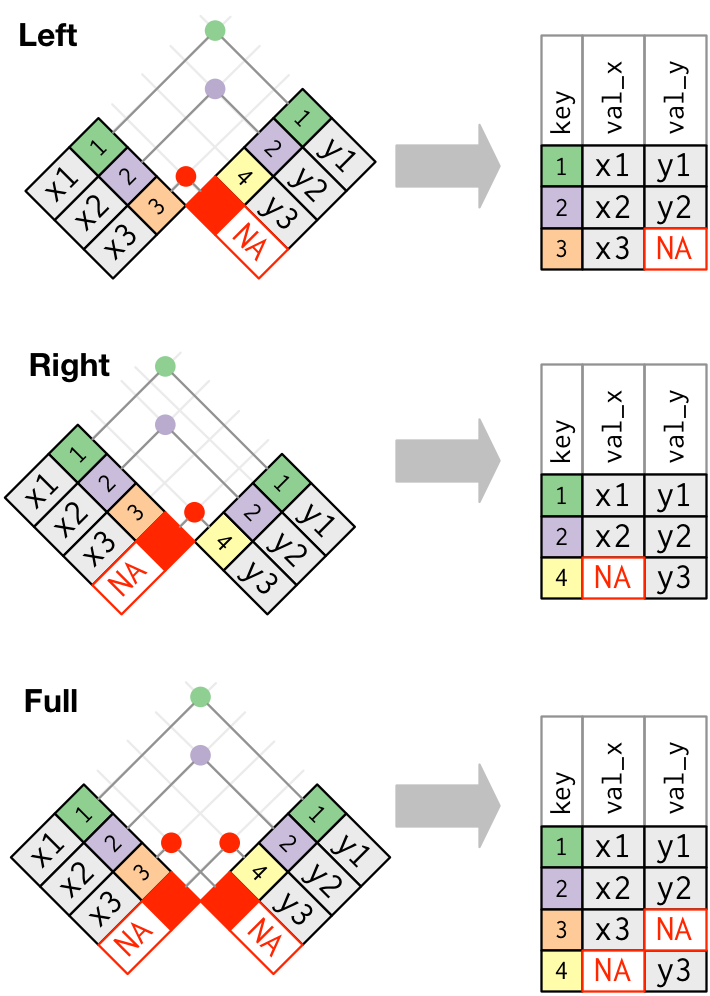

In [ ]:
dados1 <- data.frame(Cidade = c("São Paulo", "Rio de Janeiro", "Salvador"),
                     Estado = c("SP", "RJ", "BA"),
                     Time = c("Curintia", "Framengo", "Bahea"))
dados2 <- data.frame(Cidade = c("São Paulo", "Belo Horizonte", "Salvador"),
                     Estado = c("RS", "MG", "BA"),
                     Comida = c("Picanha", "Pão de queijo", "Acarajé"))

dados1
dados2

left_join(dados1, dados2, by="Cidade")
left_join(dados1, dados2, by=c("Cidade","Estado"))
right_join(dados1, dados2, by=c("Cidade","Estado"))
full_join(dados1, dados2, by=c("Cidade","Estado"))

## Exercício
Em cada tabela de eventos do heptatlo exceto a primeira, aparece a coluna `Overall rank`, que atualiza a posição de cada atleta após terminado o evento.

Obtenha uma tabela com as atletas que atualiza as posições após cada evento.

_Dica_: use uma lista e um `for` para copiar as tabelas (use `select` para escolher as colunas necessárias de cada tabela) e outro `for` para juntar as bases.

In [ ]:
# Solução
tabelas_heptatlo

In [ ]:
tabelas <- list()

tabelas[[1]] <- tabelas_heptatlo[[7]] %>%
  select(Athlete, Nation, Rank)

geral <- tabelas[[1]]

for(i in 2:7){
  tabelas[[i]] <- tabelas_heptatlo[[i+6]] %>% select(Athlete, Nation, `Overall rank`)
  geral <- left_join(geral, tabelas[[i]], by=c("Athlete", "Nation"))
}

colnames(geral)[3:9] <- paste("Event", 1:7)
geral %>% arrange(`Event 7`)

# Extra: usando o Google Drive

In [ ]:
    install.packages("googledrive")
    library("googledrive")

    if (file.exists("/usr/local/lib/python3.7/dist-packages/google/colab/_ipython.py")){
      install.packages("R.utils")
      library("R.utils")
      library("httr")
      my_check <- function() {return(TRUE)}
      reassignInPackage("is_interactive", pkgName = "httr", my_check)
      options(rlang_interactive=TRUE)

    }

In [ ]:
drive_auth(use_oob = TRUE, cache = TRUE)

In [ ]:
write_csv(cem_barreiras, file="cem_barreiras.csv")